In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"C:\MY PROJECTS\Codveda\churn-bigml-80.csv")

In [2]:
print(df.tail())

     State  Account length  Area code International plan Voice mail plan  \
2661    SC              79        415                 No              No   
2662    AZ             192        415                 No             Yes   
2663    WV              68        415                 No              No   
2664    RI              28        510                 No              No   
2665    TN              74        415                 No             Yes   

      Number vmail messages  Total day minutes  Total day calls  \
2661                      0              134.7               98   
2662                     36              156.2               77   
2663                      0              231.1               57   
2664                      0              180.8              109   
2665                     25              234.4              113   

      Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
2661             22.90              189.7               68  

In [3]:
import pandas as pd
import numpy as np
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df_clean = df.copy()

In [5]:
print(df_clean.shape)

(2666, 20)


In [6]:
print(df_clean.columns.tolist())

['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']


In [7]:
print(df_clean.dtypes)

State                         str
Account length              int64
Area code                   int64
International plan            str
Voice mail plan               str
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object


In [8]:
print(df_clean.isnull().sum())

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


In [9]:
print("Total missing values:", df_clean.isnull().sum().sum())

Total missing values: 0


In [10]:
print("Duplicate rows:", df_clean.duplicated())

Duplicate rows: 0       False
1       False
2       False
3       False
4       False
        ...  
2661    False
2662    False
2663    False
2664    False
2665    False
Length: 2666, dtype: bool


In [11]:
print (df_clean["International plan"].value_counts())

International plan
No     2396
Yes     270
Name: count, dtype: int64


In [12]:
print (df_clean["Voice mail plan"].value_counts())

Voice mail plan
No     1933
Yes     733
Name: count, dtype: int64


In [13]:
print(df_clean["State"].nunique())

51


In [14]:
print(df_clean["State"].unique())

<ArrowStringArray>
['KS', 'OH', 'NJ', 'OK', 'AL', 'MA', 'MO', 'WV', 'RI', 'IA', 'MT', 'ID', 'VT',
 'VA', 'TX', 'FL', 'CO', 'AZ', 'NE', 'WY', 'IL', 'NH', 'LA', 'GA', 'AK', 'MD',
 'AR', 'WI', 'OR', 'DE', 'IN', 'UT', 'CA', 'SD', 'NC', 'WA', 'MN', 'NM', 'NV',
 'DC', 'NY', 'KY', 'ME', 'MS', 'MI', 'SC', 'TN', 'PA', 'HI', 'ND', 'CT']
Length: 51, dtype: str


In [15]:
print(df_clean["Churn"].value_counts())

Churn
False    2278
True      388
Name: count, dtype: int64


In [16]:
print(df_clean["Churn"].value_counts(normalize=True)*100)

Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64


In [17]:
print(df_clean.describe())

       Account length    Area code  Number vmail messages  Total day minutes  \
count     2666.000000  2666.000000            2666.000000         2666.00000   
mean       100.620405   437.438860               8.021755          179.48162   
std         39.563974    42.521018              13.612277           54.21035   
min          1.000000   408.000000               0.000000            0.00000   
25%         73.000000   408.000000               0.000000          143.40000   
50%        100.000000   415.000000               0.000000          179.95000   
75%        127.000000   510.000000              19.000000          215.90000   
max        243.000000   510.000000              50.000000          350.80000   

       Total day calls  Total day charge  Total eve minutes  Total eve calls  \
count      2666.000000       2666.000000        2666.000000      2666.000000   
mean        100.310203         30.512404         200.386159       100.023631   
std          19.988162          9.21573

In [18]:
print(df_clean["Total day minutes"].describe())

count    2666.00000
mean      179.48162
std        54.21035
min         0.00000
25%       143.40000
50%       179.95000
75%       215.90000
max       350.80000
Name: Total day minutes, dtype: float64


In [19]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns
for column in numeric_columns:
    negative_values = (df_clean[column]< 0).sum()
    print(column, "negative values:", negative_values)

Account length negative values: 0
Area code negative values: 0
Number vmail messages negative values: 0
Total day minutes negative values: 0
Total day calls negative values: 0
Total day charge negative values: 0
Total eve minutes negative values: 0
Total eve calls negative values: 0
Total eve charge negative values: 0
Total night minutes negative values: 0
Total night calls negative values: 0
Total night charge negative values: 0
Total intl minutes negative values: 0
Total intl calls negative values: 0
Total intl charge negative values: 0
Customer service calls negative values: 0


In [20]:
print(df_clean["Total day minutes"].sort_values(ascending=False).head(10))

296     350.8
780     346.8
2087    345.3
128     337.4
485     335.5
1333    329.8
1612    328.1
1949    326.3
2114    322.4
2516    322.3
Name: Total day minutes, dtype: float64


In [21]:
print(df_clean["Customer service calls"].sort_values(ascending=False).head(10))

1921    9
435     9
1515    8
1343    7
714     7
268     7
2390    7
420     7
1478    7
2500    7
Name: Customer service calls, dtype: int64


In [22]:
print(
    df_clean[["Total day minutes", "Total day charge"]].head(10)
)

   Total day minutes  Total day charge
0              265.1             45.07
1              161.6             27.47
2              243.4             41.38
3              299.4             50.90
4              166.7             28.34
5              223.4             37.98
6              218.2             37.09
7              157.0             26.69
8              258.6             43.96
9              187.7             31.91


In [23]:
df_clean["Area code"].dtype

dtype('int64')

In [24]:
df_clean["Area code"] = df_clean["Area code"].astype(str)
df_clean["Area code"].dtype

<StringDtype(na_value=nan)>

In [25]:
categorical_columns = [
    "State",
    "Area code",
    "International plan",
    "Voice mail plan"
]
for column in categorical_columns:
    print("\n", column)
    print(df_clean[column].value_counts())


 State
State
WV    88
MN    70
NY    68
VA    67
OH    66
AL    66
WY    66
OR    62
WI    61
NV    61
MD    60
UT    60
CO    59
CT    59
MI    58
VT    57
ID    56
NC    56
TX    55
FL    54
IN    54
MT    53
KS    52
OK    52
MA    52
MO    51
DE    51
NJ    50
GA    49
SD    49
ME    49
SC    49
RI    48
WA    48
MS    48
AR    47
AZ    45
NE    45
IL    45
DC    45
NM    44
HI    44
ND    44
NH    43
AK    43
KY    43
TN    41
IA    38
PA    36
LA    35
CA    24
Name: count, dtype: int64

 Area code
Area code
415    1318
510     679
408     669
Name: count, dtype: int64

 International plan
International plan
No     2396
Yes     270
Name: count, dtype: int64

 Voice mail plan
Voice mail plan
No     1933
Yes     733
Name: count, dtype: int64


In [26]:
df_clean["International plan"] = (
    df_clean["International plan"]
    .map({"Yes": 1, "No": 0})
)

df_clean["Voice mail plan"] = (
    df_clean["Voice mail plan"]
    .map({"Yes": 1, "No": 0})
)


In [27]:
print(df_clean["International plan"].value_counts())
print(df_clean["Voice mail plan"].value_counts())

International plan
0    2396
1     270
Name: count, dtype: int64
Voice mail plan
0    1933
1     733
Name: count, dtype: int64


In [28]:
x = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

In [29]:
print(x.shape)
print(y.shape)

(2666, 19)
(2666,)


In [30]:
x = pd.get_dummies(
    x,
    columns=["State", "Area code"],
    drop_first=True,  
    dummy_na=True,
    dtype=int
)

In [31]:
print(x.dtypes.value_counts())

int64      63
float64     8
Name: count, dtype: int64


In [32]:
x = x.astype(int)

In [33]:
print(x.head())

   Account length  International plan  Voice mail plan  Number vmail messages  \
0             128                   0                1                     25   
1             107                   0                1                     26   
2             137                   0                0                      0   
3              84                   1                0                      0   
4              75                   1                0                      0   

   Total day minutes  Total day calls  Total day charge  Total eve minutes  \
0                265              110                45                197   
1                161              123                27                195   
2                243              114                41                121   
3                299               71                50                 61   
4                166              113                28                148   

   Total eve calls  Total eve charge  ...  S

In [34]:
print(x.shape)

(2666, 71)


In [35]:
print(x.dtypes.value_counts())

int64    71
Name: count, dtype: int64


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [38]:
print("Training:", x_train.shape)
print("Testing:", x_test.shape)

Training: (2132, 71)
Testing: (534, 71)


In [39]:
print(y_train.value_counts(normalize=True)*100)
print(y_test.value_counts(normalize=True)*100)

Churn
False    85.459662
True     14.540338
Name: proportion, dtype: float64
Churn
False    85.393258
True     14.606742
Name: proportion, dtype: float64


In [40]:
df_clean.to_csv("churn_cleaned.csv", index=False)

In [41]:
model_data = x.copy()
model_data["churn"] = y.astype(int)

In [42]:
model_data.to_csv(
    "churn_cleaned.csv",
    index=False
)

In [43]:
numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns

print("\nAverage values by churn status:")

print(
    df_clean.groupby("Churn")[numeric_columns]
    .mean()
    .T
)


Average values by churn status:
Churn                        False       True 
Account length          100.330992  102.319588
International plan        0.066725    0.304124
Voice mail plan           0.293240    0.167526
Number vmail messages     8.507463    5.170103
Total day minutes       175.104346  205.181186
Total day calls         100.159350  101.195876
Total day charge         29.768266   34.881340
Total eve minutes       198.853380  209.385309
Total eve calls         100.036435   99.948454
Total eve charge         16.902809   17.797861
Total night minutes     200.464091  205.307216
Total night calls       100.007902  100.682990
Total night charge        9.020975    9.238892
Total intl minutes       10.137840   10.819330
Total intl calls          4.538191    4.051546
Total intl charge         2.737709    2.921727
Customer service calls    1.453029    2.206186


In [44]:
print(
    pd.crosstab(
    df_clean["International plan"],
    df_clean["Churn"],
    normalize="index"
    )*100

)

Churn                   False      True 
International plan                      
0                   88.731219  11.268781
1                   56.296296  43.703704


In [45]:
print(
    pd.crosstab(
    df_clean["Voice mail plan"],
    df_clean["Churn"],
    normalize="index"
    )*100

)

Churn                False      True 
Voice mail plan                      
0                83.290222  16.709778
1                91.132333   8.867667


In [46]:
print(
    pd.crosstab(
    df_clean["Customer service calls"],
    df_clean["Churn"],
    normalize="index"
    )*100

)

Churn                       False       True 
Customer service calls                       
0                       85.765766   14.234234
1                       89.523810   10.476190
2                       89.802632   10.197368
3                       89.367816   10.632184
4                       51.879699   48.120301
5                       40.816327   59.183673
6                       41.176471   58.823529
7                       37.500000   62.500000
8                        0.000000  100.000000
9                        0.000000  100.000000


In [47]:
import matplotlib.pyplot as plt

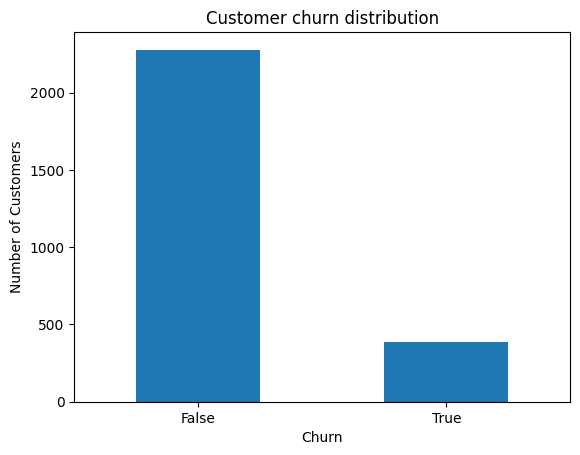

In [48]:
df_clean["Churn"].value_counts().plot(
    kind="bar"
)
plt.title("Customer churn distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

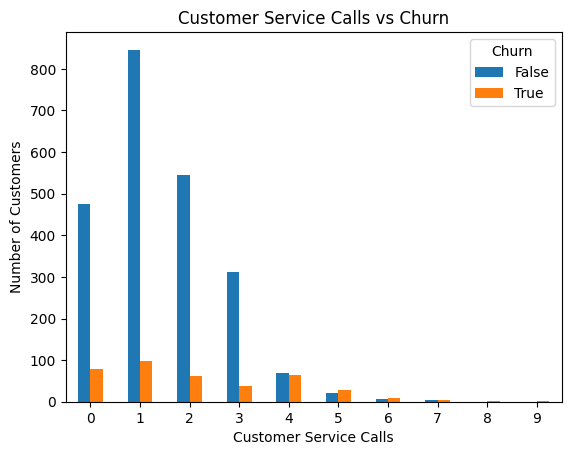

In [49]:
pd.crosstab(
    df_clean["Customer service calls"],
    df_clean["Churn"]
).plot(
    kind="bar"
)
plt.title("Customer Service Calls vs Churn")
plt.xlabel("Customer Service Calls")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [50]:
correlation = df_clean.select_dtypes(
    include=np.number
).corr()
print(correlation["Churn"].sort_values(ascending=True))

KeyError: 'Churn'

In [ ]:
# Convert Churn to numeric if it's categorical
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# Or if it's already numbers but stored as strings
df_clean["Churn"] = pd.to_numeric(df_clean["Churn"], errors="coerce")

# Now run correlation
correlation = df_clean.select_dtypes(include=np.number).corr()
print(correlation["Churn"].sort_values(ascending=False))


Account length           NaN
International plan       NaN
Voice mail plan          NaN
Number vmail messages    NaN
Total day minutes        NaN
Total day calls          NaN
Total day charge         NaN
Total eve minutes        NaN
Total eve calls          NaN
Total eve charge         NaN
Total night minutes      NaN
Total night calls        NaN
Total night charge       NaN
Total intl minutes       NaN
Total intl calls         NaN
Total intl charge        NaN
Customer service calls   NaN
Churn                    NaN
Name: Churn, dtype: float64


In [ ]:
corr_matrix = x.corr().abs()

high_corr = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)
print(high_corr.head(20)*100)

Total day minutes       Total day charge         99.950649
Total eve minutes       Total eve charge         99.768666
Total night minutes     Total night charge       99.228628
Voice mail plan         Number vmail messages    95.715891
Total intl minutes      Total intl charge        92.689821
Area code_415           Area code_510            57.802778
International plan      State_IL                  7.183240
Customer service calls  State_AR                  5.990988
Total night calls       State_TN                  5.861771
                        State_VA                  5.790324
Total day calls         State_ID                  5.649430
Total intl charge       State_NJ                  5.529253
International plan      Total intl minutes        5.489041
State_ME                Area code_510             5.461086
Total day charge        State_MD                  5.450155
Total day minutes       State_MD                  5.363859
Total eve charge        State_WV                  5.2890

In [ ]:
print("Number of feautures:", x.shape[1])
print("Training rows:", x_train.shape[0])
print("Testing rows:", x_test.shape[0])

Number of feautures: 71
Training rows: 2132
Testing rows: 534


In [ ]:
numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns
print(
    df_clean.groupby("Churn")[numeric_columns]
    .mean()
    .T
)

Empty DataFrame
Columns: []
Index: [Account length, International plan, Voice mail plan, Number vmail messages, Total day minutes, Total day calls, Total day charge, Total eve minutes, Total eve calls, Total eve charge, Total night minutes, Total night calls, Total night charge, Total intl minutes, Total intl calls, Total intl charge, Customer service calls, Churn]


In [ ]:
print(df_clean.dtypes)

State                         str
Account length              int64
Area code                     str
International plan          int64
Voice mail plan             int64
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object


In [ ]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns
print(
    df_clean.groupby("Churn")[numeric_columns]
    .mean()
    .T
)

Churn                        False       True 
Account length          100.330992  102.319588
International plan        0.066725    0.304124
Voice mail plan           0.293240    0.167526
Number vmail messages     8.507463    5.170103
Total day minutes       175.104346  205.181186
Total day calls         100.159350  101.195876
Total day charge         29.768266   34.881340
Total eve minutes       198.853380  209.385309
Total eve calls         100.036435   99.948454
Total eve charge         16.902809   17.797861
Total night minutes     200.464091  205.307216
Total night calls       100.007902  100.682990
Total night charge        9.020975    9.238892
Total intl minutes       10.137840   10.819330
Total intl calls          4.538191    4.051546
Total intl charge         2.737709    2.921727
Customer service calls    1.453029    2.206186


In [ ]:
print(df_clean.dtypes)

State                         str
Account length              int64
Area code                     str
International plan          int64
Voice mail plan             int64
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object


In [ ]:
print(df_clean.dtypes.value_counts())

int64      9
float64    8
str        2
bool       1
Name: count, dtype: int64


In [ ]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns
churn_comperison = (
    df_clean.groupby("Churn")[numeric_columns]
    .mean()
    .T
)
print(churn_comperison)

Churn                        False       True 
Account length          100.330992  102.319588
International plan        0.066725    0.304124
Voice mail plan           0.293240    0.167526
Number vmail messages     8.507463    5.170103
Total day minutes       175.104346  205.181186
Total day calls         100.159350  101.195876
Total day charge         29.768266   34.881340
Total eve minutes       198.853380  209.385309
Total eve calls         100.036435   99.948454
Total eve charge         16.902809   17.797861
Total night minutes     200.464091  205.307216
Total night calls       100.007902  100.682990
Total night charge        9.020975    9.238892
Total intl minutes       10.137840   10.819330
Total intl calls          4.538191    4.051546
Total intl charge         2.737709    2.921727
Customer service calls    1.453029    2.206186


In [ ]:
international_churn = pd.crosstab(
    df_clean["International plan"],
    df_clean["Churn"],
    normalize="index"
)*100
print(international_churn)

Churn                   False      True 
International plan                      
0                   88.731219  11.268781
1                   56.296296  43.703704


In [ ]:
voicemail_churn = pd.crosstab(
    df_clean["Voice mail plan"],
    df_clean["Churn"],
    normalize="index"
)*100
print(voicemail_churn)

Churn                False      True 
Voice mail plan                      
0                83.290222  16.709778
1                91.132333   8.867667


In [ ]:
service_churn = pd.crosstab(
    df_clean["Customer service calls"],
    df_clean["Churn"],
    normalize="index"
)*100
print(service_churn)

Churn                       False       True 
Customer service calls                       
0                       85.765766   14.234234
1                       89.523810   10.476190
2                       89.802632   10.197368
3                       89.367816   10.632184
4                       51.879699   48.120301
5                       40.816327   59.183673
6                       41.176471   58.823529
7                       37.500000   62.500000
8                        0.000000  100.000000
9                        0.000000  100.000000


In [ ]:
voice_churn = pd.crosstab(
    df_clean["Total day calls"],
    df_clean["Churn"],
    normalize="index"
)*100
print(voice_churn)

Churn                 False       True 
Total day calls                        
0                 50.000000   50.000000
36               100.000000    0.000000
40               100.000000    0.000000
42                50.000000   50.000000
44                33.333333   66.666667
...                     ...         ...
152              100.000000    0.000000
156                0.000000  100.000000
157              100.000000    0.000000
158              100.000000    0.000000
160              100.000000    0.000000

[115 rows x 2 columns]


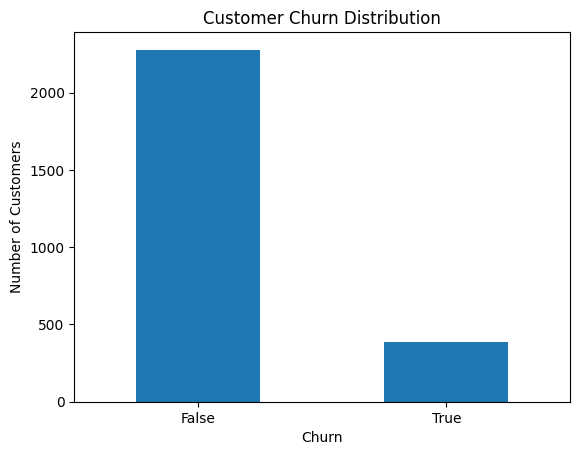

In [ ]:
import matplotlib.pyplot as plt
df_clean["Churn"].value_counts().plot(
    kind="bar"
)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

C:\Users\dave\AppData\Local\Temp\ipykernel_3992\2285147491.py:12: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(["Stayed"], ["Churned"])


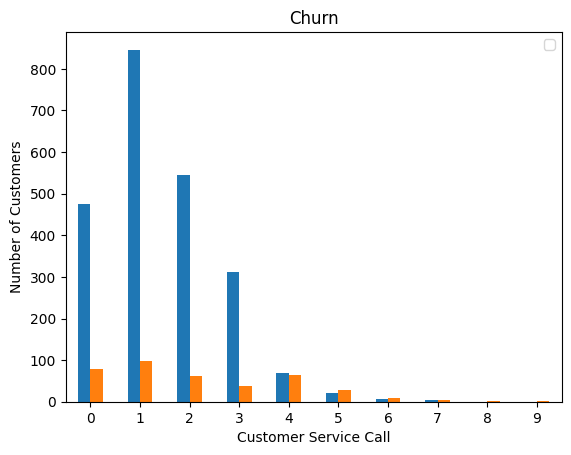

In [ ]:
import matplotlib.pyplot as plt
pd.crosstab(
    df_clean["Customer service calls"],
    df_clean["Churn"]
).plot(
    kind="bar"
)
plt.title("Churn")
plt.xlabel("Customer Service Call")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["Stayed"], ["Churned"])
plt.show()

In [ ]:
correlation = df_clean.corr(numeric_only=True)["Churn"].sort_values(
    ascending=False
)
print(correlation)

Churn                     1.000000
International plan        0.277489
Customer service calls    0.202590
Total day charge          0.195689
Total day minutes         0.195688
Total intl charge         0.086216
Total intl minutes        0.086204
Total eve minutes         0.072906
Total eve charge          0.072893
Total night minutes       0.033639
Total night charge        0.033635
Total day calls           0.018290
Account length            0.017728
Total night calls         0.012262
Total eve calls          -0.001539
Total intl calls         -0.069882
Number vmail messages    -0.086474
Voice mail plan          -0.099291
Name: Churn, dtype: float64


In [ ]:
corr_matrix = df_clean.corr(numeric_only=True)

high_corr=(
    corr_matrix
    .where(
        (corr_matrix.abs()> 0.90)&
        (corr_matrix.abs()<1.00)
    )
    .stack()
    .sort_values(ascending=False)
)
print(high_corr)

Total day charge     Total day minutes         1.000000
Total day minutes    Total day charge          1.000000
Total eve minutes    Total eve charge          1.000000
Total eve charge     Total eve minutes         1.000000
Total night minutes  Total night charge        0.999999
                                                 ...   
Churn                Total intl minutes             NaN
                     Total intl calls               NaN
                     Total intl charge              NaN
                     Customer service calls         NaN
                     Churn                          NaN
Length: 324, dtype: float64


In [ ]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns
churn_comperison = (
    df_clean.groupby("Churn")[numeric_columns]
    .mean()
    .T
)
print(churn_comperison)

Churn                        False       True 
Account length          100.330992  102.319588
International plan        0.066725    0.304124
Voice mail plan           0.293240    0.167526
Number vmail messages     8.507463    5.170103
Total day minutes       175.104346  205.181186
Total day calls         100.159350  101.195876
Total day charge         29.768266   34.881340
Total eve minutes       198.853380  209.385309
Total eve calls         100.036435   99.948454
Total eve charge         16.902809   17.797861
Total night minutes     200.464091  205.307216
Total night calls       100.007902  100.682990
Total night charge        9.020975    9.238892
Total intl minutes       10.137840   10.819330
Total intl calls          4.538191    4.051546
Total intl charge         2.737709    2.921727
Customer service calls    1.453029    2.206186


In [66]:
international_churn = pd.crosstab(
    df_clean["International plan"],
    df_clean["Churn"],
    normalize="index"
)*100
print(international_churn)

Churn                   False      True 
International plan                      
0                   88.731219  11.268781
1                   56.296296  43.703704


In [65]:
voicemail_churn = pd.crosstab(
    df_clean["Voice mail plan"],
    df_clean["Churn"],
    normalize="index"
)*100
print(voicemail_churn)

Churn                False      True 
Voice mail plan                      
0                83.290222  16.709778
1                91.132333   8.867667


In [67]:
service_churn = pd.crosstab(
    df_clean["Customer service calls"],
    df_clean["Churn"],
    normalize="index"
)*100
print(service_churn)

Churn                       False       True 
Customer service calls                       
0                       85.765766   14.234234
1                       89.523810   10.476190
2                       89.802632   10.197368
3                       89.367816   10.632184
4                       51.879699   48.120301
5                       40.816327   59.183673
6                       41.176471   58.823529
7                       37.500000   62.500000
8                        0.000000  100.000000
9                        0.000000  100.000000


In [64]:
correlation = df_clean.corr(
    numeric_only=True
)["Churn"].sort_values(
    ascending=False
)
print(correlation)

Churn                     1.000000
International plan        0.277489
Customer service calls    0.202590
Total day charge          0.195689
Total day minutes         0.195688
Total intl charge         0.086216
Total intl minutes        0.086204
Total eve minutes         0.072906
Total eve charge          0.072893
Total night minutes       0.033639
Total night charge        0.033635
Total day calls           0.018290
Account length            0.017728
Total night calls         0.012262
Total eve calls          -0.001539
Total intl calls         -0.069882
Number vmail messages    -0.086474
Voice mail plan          -0.099291
Name: Churn, dtype: float64


In [68]:
charge_columns = [
    "Total day charge"
    "Total eve charge"
    "Total night charge"
    "Total intl charge"
]

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder

model_df = pd.read_csv(r"C:\MY PROJECTS\Codveda\churn-bigml-80.csv")
y = model_df["Churn"].astype(int)
x = model_df.drop("Churn", axis=1).copy()
x["Area code"] = x["Area code"].astype(str)

charge_columns = [
    "Total day charge",
    "Total eve charge",
    "Total night charge",
    "Total intl charge"
]
x = x.drop(columns=charge_columns)
print("Features:", x.shape)
print("Target:", y.shape)




Features: (2666, 15)
Target: (2666,)


In [60]:
categorical_columns = [
    "State",
    "Area code",
    "International plan",
    "Voice mail plan"
]
numerical_columns = [
    column for column in x.columns
    if column not in categorical_columns
]
print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['State', 'Area code', 'International plan', 'Voice mail plan']

Numerical columns:
['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'State_AL', 'State_AR', 'State_AZ', 'State_CA', 'State_CO', 'State_CT', 'State_DC', 'State_DE', 'State_FL', 'State_GA', 'State_HI', 'State_IA', 'State_ID', 'State_IL', 'State_IN', 'State_KS', 'State_KY', 'State_LA', 'State_MA', 'State_MD', 'State_ME', 'State_MI', 'State_MN', 'State_MO', 'State_MS', 'State_MT', 'State_NC', 'State_ND', 'State_NE', 'State_NH', 'State_NJ', 'State_NM', 'State_NV', 'State_NY', 'State_OH', 'State_OK', 'State_OR', 'State_PA', 'State_RI', 'State_SC', 'State_SD', 'State_TN', 'State_TX', 'State_UT', 'State_VA', 'State_VT', 'State_WA', 'State_WI', 

In [58]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training date:", x_train.shape)
print("Testing data:", x_test.shape)

Training date: (2132, 71)
Testing data: (534, 71)


In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numerical_columns
        ),
        (
            "categotical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_columns
        )
    ]
)

In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Automatically detect column types
numeric_features = x_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = x_train.select_dtypes(include=["object", "category"]).columns

# Define preprocessing for each type
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Build the pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Fit and predict
logistic_model.fit(x_train, y_train)
logistic_predictions = logistic_model.predict(x_test)
logistic_probabilities = logistic_model.predict_proba(x_test)[:, 1]

print("Logistic Regression trained successfully.")


Logistic Regression trained successfully.


In [77]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=6,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)
tree_model.fit(x_train, y_train)
tree_prediction = tree_model.predict(x_test)
tree_probabilities = tree_model.predict_proba(x_test)[:, 1]

print("Decision Tree trained successfully")

Decision Tree trained successfully


In [78]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
                min_samples_leaf=2
            )
        )
    ]
)
random_forest_model.fit(x_train, y_train)
rf_predictions = random_forest_model.predict(x_test)
rf_probabilities = random_forest_model.predict_proba(x_test)[:, 1]
print("Random Forest trained successfully")

Random Forest trained successfully


In [55]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
def evaluate_model(name, y_true, predictions, probabilities):
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions),
        "Recall": recall_score(y_true, predictions),
        "F1 Score": f1_score(y_true, predictions),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }
    return results

In [79]:

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)
results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_prediction,
        tree_probabilities
    )
)
results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probabilities
    )
)
results_df = pd.DataFrame(results)
print(results_df.round(3))



                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     0.742      0.305   0.603     0.405    0.740
1        Decision Tree     0.890      0.600   0.731     0.659    0.854
2        Random Forest     0.946      0.962   0.654     0.779    0.872


[[454   2]
 [ 27  51]]


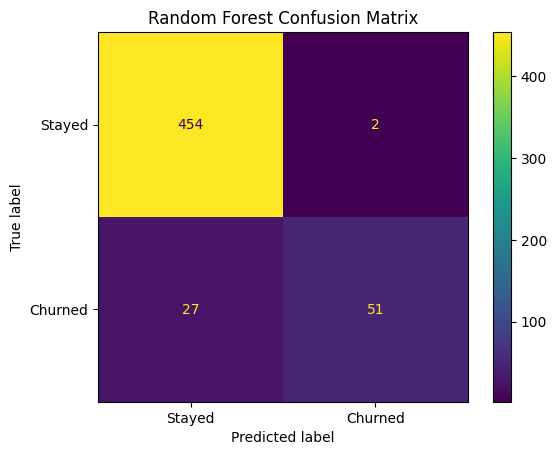

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(
    y_test,
    rf_predictions
)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

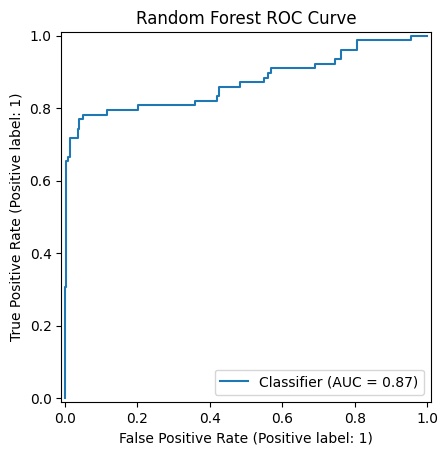

In [81]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(
    y_test,
    rf_probabilities
)
plt.title("Random Forest ROC Curve")
plt.show()

In [82]:
feature_name = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)
importance = (
    random_forest_model
    .named_steps["model"]
    .feature_importances_
)
feature_importance = pd.DataFrame({
    "Feature": feature_name,
    "Importance": importance
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print(feature_importance.head(15))

                        Feature  Importance
4        num__Total day minutes    0.136953
16  num__Customer service calls    0.136581
6         num__Total day charge    0.116959
1       num__International plan    0.087672
7        num__Total eve minutes    0.055444
10     num__Total night minutes    0.045240
0           num__Account length    0.040630
11       num__Total night calls    0.039519
9         num__Total eve charge    0.038411
5          num__Total day calls    0.038326
14        num__Total intl calls    0.037383
8          num__Total eve calls    0.036859
13      num__Total intl minutes    0.035402
12      num__Total night charge    0.023978
3    num__Number vmail messages    0.023457


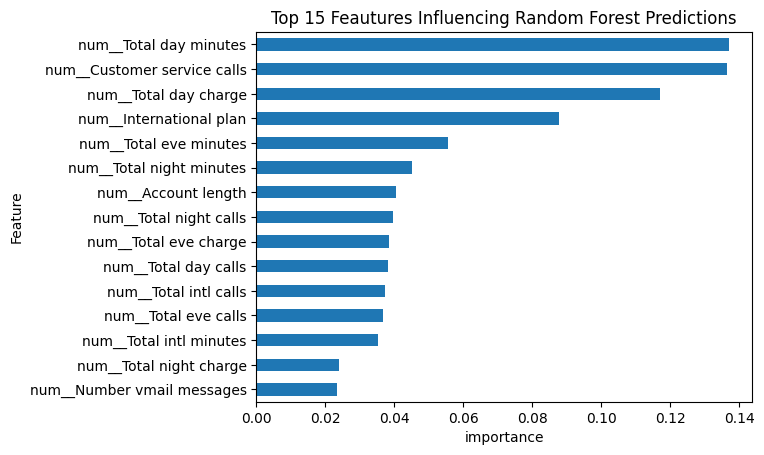

In [83]:
feature_importance.head(15).sort_values(
    "Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)
plt.title("Top 15 Feautures Influencing Random Forest Predictions")
plt.xlabel("importance")
plt.ylabel("Feature")
plt.show()

In [71]:
import joblib
joblib.dump(
    random_forest_model,
    "churn_model.pkl"
)
print("Model successfuly saved")

Model successfuly saved


In [2]:
def predict_churn(customer):
    customer_df = pd.DataFrame([customer])
    probability = random_forest_model.predict_proba(
        customer_df
    )[0][1]
    prediction = random_forest_model.predict(
        customer_df
    )[0]
    if prediction == 1:
        result = "Likely to Churn"
    else:
        result = "Likely to Stay"  

    print("Prediction:", result)  
    print(f"Churn probability: {probability:.2%}")
    return result, probability

In [3]:
def predict_churn(customer):

    # Convert the customer information into a DataFrame
    customer_df = pd.DataFrame([customer])

    # Make Area code the same type used during training
    customer_df["Area code"] = customer_df["Area code"].astype(str)

    # Make sure the customer has exactly the features used by the model
    customer_df = customer_df[X.columns]

    # Get churn probability
    probability = random_forest_model.predict_proba(
        customer_df
    )[0][1]

    # Get prediction
    prediction = random_forest_model.predict(
        customer_df
    )[0]

    if prediction == 1:
        result = "Likely to Churn"
    else:
        result = "Likely to Stay"

    print("Prediction:", result)
    print(f"Churn probability: {probability:.2%}")

    return result, probability

In [89]:
new_customer = {
    "State": "OH",
    "Account length": 100,
    "Area code": "415",
    "International plan": "Yes",
    "Voice mail plan": "No",
    "Number vmail messages": 0,
    "Total day minutes": 220,
    "Total day calls": 100,
    "Total eve minutes": 210,
    "Total eve calls": 100,
    "Total night minutes": 205,
    "Total night calls": 100,
    "Total intl minutes": 12,
    "Total intl calls": 4,
    "Customer service calls": 4
}


In [4]:
def predict_churn(customer):

    # Convert customer information to a DataFrame
    customer_df = pd.DataFrame([customer])

    # Make Area code the same type used during training
    customer_df["Area code"] = customer_df["Area code"].astype(str)

    # Remove the charge columns because they were removed during model training
    charge_columns = [
        "Total day charge",
        "Total eve charge",
        "Total night charge",
        "Total intl charge"
    ]

    customer_df = customer_df.drop(
        columns=charge_columns,
        errors="ignore"
    )

    # Get prediction probability
    probability = random_forest_model.predict_proba(
        customer_df
    )[0][1]

    # Get prediction
    prediction = random_forest_model.predict(
        customer_df
    )[0]

    if prediction == 1:
        result = "Likely to Churn"
    else:
        result = "Likely to Stay"

    print("Prediction:", result)
    print(f"Churn probability: {probability:.2%}")

    return result, probability

In [93]:
import joblib
random_forest_model = joblib.load("churn_model.pkl")
print("Model loaded successfully.")

Model loaded successfully.


In [105]:
predict_churn(new_customer)

Prediction: Likely to Stay
Churn probability: 48.32%


('Likely to Stay', np.float64(0.48324180976091335))

In [96]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------
# 1. Load the original dataset
# ---------------------------------------

model_df = pd.read_csv("../churn-bigml-80.csv")

# ---------------------------------------
# 2. Separate target and features
# ---------------------------------------

y = model_df["Churn"].astype(int)

X = model_df.drop("Churn", axis=1).copy()

# ---------------------------------------
# 3. Treat Area code as categorical
# ---------------------------------------

X["Area code"] = X["Area code"].astype(str)

# ---------------------------------------
# 4. Remove redundant charge columns
# ---------------------------------------

charge_columns = [
    "Total day charge",
    "Total eve charge",
    "Total night charge",
    "Total intl charge"
]

X = X.drop(columns=charge_columns)

# ---------------------------------------
# 5. Define categorical columns
# ---------------------------------------

categorical_columns = [
    "State",
    "Area code",
    "International plan",
    "Voice mail plan"
]

# ---------------------------------------
# 6. Define numerical columns
# ---------------------------------------

numerical_columns = [
    column for column in X.columns
    if column not in categorical_columns
]

# ---------------------------------------
# 7. Create preprocessing
# ---------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numerical_columns
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_columns
        )
    ]
)

# ---------------------------------------
# 8. Create Random Forest pipeline
# ---------------------------------------

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
                min_samples_leaf=2
            )
        )
    ]
)

# ---------------------------------------
# 9. Split data
# ---------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ---------------------------------------
# 10. TRAIN THE MODEL
# ---------------------------------------

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

# ---------------------------------------
# 11. Save the TRAINED model
# ---------------------------------------

joblib.dump(
    random_forest_model,
    "churn_model.pkl"
)

print("Trained model saved successfully!")

Random Forest model trained successfully!
Trained model saved successfully!


In [99]:
from sklearn.utils.validation import check_is_fitted
check_is_fitted(random_forest_model,)
print("SUCCESS: The model is fitted and ready for predictions.")

SUCCESS: The model is fitted and ready for predictions.


In [100]:
predictions = random_forest_model.predict(X_test)
print("Predictions made successfully.")
print("Number of predictions:", len(predictions))

Predictions made successfully.
Number of predictions: 534


In [101]:
from sklearn.metrics import accuracy_score, classification_report
predictions = random_forest_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))


Accuracy: 0.9344569288389513

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       456
           1       0.85      0.67      0.75        78

    accuracy                           0.93       534
   macro avg       0.90      0.82      0.86       534
weighted avg       0.93      0.93      0.93       534



In [102]:
new_customer 
predict_churn(new_customer)

Prediction: Likely to Stay
Churn probability: 48.32%


('Likely to Stay', np.float64(0.48324180976091335))

In [103]:
def predict_churn(customer):

    customer_df = pd.DataFrame([customer])

    customer_df["Area code"] = customer_df["Area code"].astype(str)

    prediction = random_forest_model.predict(customer_df)[0]

    probability = random_forest_model.predict_proba(
        customer_df
    )[0][1]

    if prediction == 1:
        result = "Likely to Churn"
    else:
        result = "Likely to Stay"

    print("Prediction:", result)
    print(f"Churn probability: {probability:.2%}")

    return result, probability

In [104]:
predict_churn(new_customer)

Prediction: Likely to Stay
Churn probability: 48.32%


('Likely to Stay', np.float64(0.48324180976091335))

In [106]:
df_clean.to_csv("churn_cleaned.csv", index=False)
x.to_csv(
    "churn_model_ready.csv", index=False
)
print("Cleaned and model-ready datasets saved successfully!")

Cleaned and model-ready datasets saved successfully!


In [5]:
# ==========================================
# FINAL CHURN MODEL PIPELINE
# ==========================================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ==========================================
# 1. LOAD DATA
# ==========================================

df = pd.read_csv("churn-bigml-80.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)


# ==========================================
# 2. DEFINE TARGET
# ==========================================

X = df.drop("Churn", axis=1)

y = df["Churn"].astype(int)


# ==========================================
# 3. MAKE AREA CODE CATEGORICAL
# ==========================================

X["Area code"] = X["Area code"].astype(str)


# ==========================================
# 4. DEFINE CATEGORICAL COLUMNS
# ==========================================

categorical_columns = [
    "State",
    "Area code",
    "International plan",
    "Voice mail plan"
]


# ==========================================
# 5. DEFINE NUMERICAL COLUMNS
# ==========================================

numerical_columns = [
    column for column in X.columns
    if column not in categorical_columns
]


print("\nCategorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)


# ==========================================
# 6. NUMERICAL PREPROCESSING
# ==========================================

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)


# ==========================================
# 7. CATEGORICAL PREPROCESSING
# ==========================================

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ==========================================
# 8. COMBINE PREPROCESSING
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numerical_columns
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns
        )
    ]
)


# ==========================================
# 9. CREATE RANDOM FOREST MODEL
# ==========================================

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)


# ==========================================
# 10. CREATE COMPLETE PIPELINE
# ==========================================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", random_forest)
    ]
)


# ==========================================
# 11. SPLIT DATA
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))


# ==========================================
# 12. TRAIN MODEL
# ==========================================

model.fit(X_train, y_train)

print("\nModel trained successfully!")


# ==========================================
# 13. TEST MODEL
# ==========================================

y_pred = model.predict(X_test)


# ==========================================
# 14. MODEL PERFORMANCE
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# ==========================================
# 15. SAVE COMPLETE PIPELINE
# ==========================================

joblib.dump(
    model,
    "churn_model.pkl"
)

print("\n================================")
print("MODEL SAVED SUCCESSFULLY!")
print("File: churn_model.pkl")
print("================================")


Dataset loaded successfully
Shape: (2666, 20)

Categorical columns:
['State', 'Area code', 'International plan', 'Voice mail plan']

Numerical columns:
['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']

Training rows: 2132
Testing rows: 534

Model trained successfully!

Accuracy: 0.9307

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       456
           1       1.00      0.53      0.69        78

    accuracy                           0.93       534
   macro avg       0.96      0.76      0.83       534
weighted avg       0.94      0.93      0.92       534


Confusion Matrix:
[[456   0]
 [ 37  41]]

MODEL SAVED SUCCESSFULLY!
File: churn_model.pkl
